# AIG230 – Assignment 6 (Part B Starter Notebook)
## Neural Language Model with PyTorch (RNN) – Student Version

This notebook covers **all of Part B**:

- **B1** Numericalization + training examples  
- **B2** Build an RNN Language Model  
- **B3** Train + validate (loss + perplexity)  
- **B4** Test perplexity + text generation  

### Dataset (same as Part A)
- **NLTK Brown corpus**, category: `news`

### Important
This is a **starter notebook**. You must complete the **TODO** blocks.  
Do not delete TODO comments. Add your code underneath them.


In [2]:
%pip install torch nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Solma\OneDrive\Desktop\Lab230\Assignment 5\aig230-env\Scripts\python.exe -m pip install --upgrade pip


In [22]:
# ===== 1) Setup =====
import re
import math
import random
from collections import Counter
from dataclasses import dataclass
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.corpus import brown

# Download if needed (safe to run multiple times)
nltk.download('brown')

# Reproducibility (optional)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\Solma\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [42]:
# ===== 2) Configuration (edit if needed) =====
# You can edit these hyperparameters as needed. The defaults should work for a basic run.
# This are not fixed rules, just a starting point. Feel free to experiment with different values!
# This parameter class is just a convenient way to store all the settings in one place. You can also use a dictionary or command-line arguments if you prefer.
# These parameters define the dataset category, how to split the data, vocabulary cutoff, model architecture, and training settings. Adjusting these can affect the performance and training time of your model.
@dataclass
class Config:
    category: str = "news"
    train_ratio: float = 0.80
    val_ratio: float = 0.10
    test_ratio: float = 0.10

    min_freq: int = 2       # vocab cutoff (train only)
    seq_len: int = 30       # T
    batch_size: int = 128

    emb_dim: int = 128
    hid_dim: int = 64
    num_layers: int = 1
    dropout: float = 0.0    # use 0.0 if num_layers == 1

    lr: float = 1e-3
    epochs: int = 5
    grad_clip: float = 1.0  # optional but recommended

cfg = Config()

SPECIAL = {"BOS": "<bos>", "EOS": "<eos>", "UNK": "<unk>"}


# 3) Load + preprocess Brown (shared rules)

Preprocessing rules:
- lowercase
- remove punctuation-only tokens
- keep stopwords
- add `<bos>` and `<eos>` to each sentence


In [43]:
# ===== 3) Load Brown sentences =====
# This section loads the raw sentences from the Brown corpus, preprocesses them by lowercasing and removing punctuation-only tokens, and adds special tokens for the beginning and end of sentences. The resulting `sents` variable is a list of tokenized sentences ready for building the vocabulary and training the model.
raw_sents: List[List[str]] = brown.sents(categories=cfg.category)
print("Raw sentences:", len(raw_sents))
print("Example raw:", raw_sents[0][:20])

_punct_only = re.compile(r"^\W+$")

def preprocess_sentence(tokens: List[str]) -> List[str]:
    out = []
    for tok in tokens:
        tok = tok.lower()
        if _punct_only.match(tok):
            continue
        out.append(tok)
    return [SPECIAL["BOS"], *out, SPECIAL["EOS"]]

sents = [preprocess_sentence(s) for s in raw_sents]
print("Example preprocessed:", sents[0][:25])


Raw sentences: 4623
Example raw: ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that']
Example preprocessed: ['<bos>', 'the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', '<eos>']


# 4) Split train/val/test (by sentence)

Split by sentence to avoid leakage.


In [44]:
# ===== 4) Split =====
# This section splits the preprocessed sentences into training, validation, and test sets based on the specified ratios in the configuration. It also defines a helper function to count the total number of tokens in each split and prints out the number of sentences and tokens for each set.
n = len(sents)
n_train = int(cfg.train_ratio * n)
n_val = int(cfg.val_ratio * n)
n_test = n - n_train - n_val

train_sents = sents[:n_train]
val_sents = sents[n_train:n_train+n_val]
test_sents = sents[n_train+n_val:]

def num_tokens(slist: List[List[str]]) -> int:
    return sum(len(s) for s in slist)

print("Train:", len(train_sents), "sentences |", num_tokens(train_sents), "tokens")
print("Val  :", len(val_sents),   "sentences |", num_tokens(val_sents),   "tokens")
print("Test :", len(test_sents),  "sentences |", num_tokens(test_sents),  "tokens")


Train: 3698 sentences | 77918 tokens
Val  : 462 sentences | 10264 tokens
Test : 463 sentences | 9656 tokens


# 5) Build vocabulary (train only)

Words with frequency `< min_freq` become `<unk>`.


In [45]:
# ===== 5) Vocabulary =====
# This section builds the vocabulary from the training sentences by counting the frequency of each token and including only those that meet the minimum frequency threshold specified in the configuration. 
# It also creates mappings from tokens to indices (`stoi`) and from indices to tokens (`itos`), and prints out some statistics about the vocabulary and the most common tokens in the training set.
train_tokens = [tok for sent in train_sents for tok in sent]
counts = Counter(train_tokens)

itos = [SPECIAL["BOS"], SPECIAL["EOS"], SPECIAL["UNK"]]
stoi: Dict[str, int] = {tok: i for i, tok in enumerate(itos)}

for tok, c in counts.most_common():
    if tok in stoi:
        continue
    if c >= cfg.min_freq:
        stoi[tok] = len(itos)
        itos.append(tok)

vocab_size = len(itos)
unk_id = stoi[SPECIAL["UNK"]]

print("min_freq:", cfg.min_freq)
print("vocab_size:", vocab_size)
print("UNK id:", unk_id)
print("\nTop 15 tokens (train):")
for tok, c in counts.most_common(15):
    print(f"{tok:>12}  {c}")


min_freq: 2
vocab_size: 5353
UNK id: 2

Top 15 tokens (train):
         the  5072
       <bos>  3698
       <eos>  3698
          of  2321
         and  1740
           a  1710
          to  1649
          in  1592
         for  787
        that  644
          is  575
         was  566
          on  538
          at  531
          he  509


# 6) B1 – Numericalize + create training examples (Option 1)

You will:
1) Convert each sentence into token IDs  
2) Concatenate into one long stream per split  
3) Build a Dataset that returns:
- `x = stream[i : i+T]`
- `y = stream[i+1 : i+T+1]`

Complete the TODO blocks below.


In [46]:
# ===== 6.1) Numericalize (TODO) =====
# This function converts a list of tokens into a list of corresponding token IDs using the `stoi` mapping. 
# If a token is not found in the vocabulary, it uses the `unk_id` to represent it. This step is essential for preparing the data to be fed into the model, as models typically work with numerical representations of text.
# Why this is neccessary? Models cannot process raw text; they require numerical input. By converting tokens to their corresponding IDs, we can efficiently represent the text data in a format suitable for training neural networks. This also allows us to handle out-of-vocabulary tokens gracefully using the `unk_id`.
# How this connect to the embedding layer? The embedding layer takes token IDs as input and maps them to dense vector representations (embeddings). 
# By numericalizing the sentences, we can feed these token IDs into the embedding layer, which will then produce the corresponding embeddings for each token. This is a crucial step in the pipeline, as it allows us to convert raw text into a format that can be processed by the neural network.
def numericalize_sentence(tokens: List[str], stoi: Dict[str, int], unk_id: int) -> List[int]:
    # TODO: return list of token IDs for this sentence
    # Hint: use stoi.get(tok, unk_id)
    raise NotImplementedError
# ===== 6.1) Numericalize (TODO) written by me =====
def numericalize_sentence(tokens: List[str], stoi: Dict[str, int], unk_id: int) -> List[int]:
    # Return list of token IDs for this sentence
    # Use stoi.get(tok, unk_id) to look up the ID, defaulting to unk_id if not found
    return [stoi.get(tok, unk_id) for tok in tokens]

train_ids_sents = [numericalize_sentence(s, stoi, unk_id) for s in train_sents]
val_ids_sents   = [numericalize_sentence(s, stoi, unk_id) for s in val_sents]
test_ids_sents  = [numericalize_sentence(s, stoi, unk_id) for s in test_sents]

print("Example tokens:", train_sents[0][:12])
print("Example ids   :", train_ids_sents[0][:12])



Example tokens: ['<bos>', 'the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's"]
Example ids   : [0, 3, 603, 115, 451, 145, 20, 190, 29, 886, 4, 3528]


In [47]:
# ===== 6.2) Build streams =====
train_stream = [tid for sent in train_ids_sents for tid in sent]
val_stream   = [tid for sent in val_ids_sents   for tid in sent]
test_stream  = [tid for sent in test_ids_sents  for tid in sent]

print("Train stream length:", len(train_stream))
print("Val   stream length:", len(val_stream))
print("Test  stream length:", len(test_stream))


Train stream length: 77918
Val   stream length: 10264
Test  stream length: 9656


In [48]:


# ===== 6.3) Dataset (TODO) =====
class NextTokenStreamDataset(Dataset):
    def __init__(self, token_stream: List[int], seq_len: int):
        self.stream = token_stream
        self.T = seq_len

    def __len__(self) -> int:
        # Return total number of possible sequences of length T+1
        return len(self.stream) - self.T

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # Create x (input) and y (target) slices
        # x is from idx to idx + T
        # y is from idx + 1 to idx + T + 1 (shifted by one)
        x = self.stream[idx : idx + self.T]
        y = self.stream[idx + 1 : idx + self.T + 1]
        
        # Convert to torch.long tensors
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_ds = NextTokenStreamDataset(train_stream, cfg.seq_len)
val_ds   = NextTokenStreamDataset(val_stream,   cfg.seq_len)
test_ds  = NextTokenStreamDataset(test_stream,  cfg.seq_len)

print("Train examples:", len(train_ds))

Train examples: 77888


In [11]:
# ===== 6.4) DataLoaders + sanity check (run after TODOs are done) =====
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, drop_last=True)

x_batch, y_batch = next(iter(train_loader))
print("x_batch shape:", x_batch.shape)  # expected: (B, T)
print("y_batch shape:", y_batch.shape)  # expected: (B, T)
print("x_batch dtype:", x_batch.dtype)

print("First 10 x:", x_batch[0][:10].tolist())
print("First 10 y:", y_batch[0][:10].tolist())


x_batch shape: torch.Size([32, 30])
y_batch shape: torch.Size([32, 30])
x_batch dtype: torch.int64
First 10 x: [2, 971, 5, 3127, 2, 398, 1, 0, 3, 1275]
First 10 y: [971, 5, 3127, 2, 398, 1, 0, 3, 1275, 70]


# 7) B2 – Build the RNN Language Model

Model requirements:
- Embedding layer
- RNN layer (`nn.RNN`)
- Linear layer to vocab size

Complete the TODO blocks.


In [49]:


# ===== 7) Model (TODO) =====
# Configuration class is defined at the top of the notebook. You can adjust the hyperparameters there as needed.
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hid_dim: int, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        # Define embedding layer
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        # Define RNN layer (batch_first=True ensures input is (Batch, Time, Feature))
        self.rnn = nn.RNN(emb_dim, hid_dim, num_layers, batch_first=True, dropout=dropout)
        # Define output projection layer (hid_dim -> vocab_size)
        self.linear = nn.Linear(hid_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T) token IDs
        
        # 1. Embed: (B, T) -> (B, T, E)
        embedded = self.embedding(x)
        
        # 2. RNN: (B, T, E) -> (B, T, H), (1, B, H)
        rnn_out, _ = self.rnn(embedded)
        
        # 3. Project: (B, T, H) -> (B, T, V)
        logits = self.linear(rnn_out)
        
        # Return logits: (B, T, V)
        return logits

# Instantiate model (after TODOs)
model = RNNLanguageModel(
    vocab_size=vocab_size,
    emb_dim=cfg.emb_dim,
    hid_dim=cfg.hid_dim,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout
).to(device)

# Parameter count
num_params = sum(p.numel() for p in model.parameters())
print("Model parameters:", num_params)

Model parameters: 1045545


# 8) B3 – Training + validation (loss + perplexity)

You will:
- Define loss (`CrossEntropyLoss`)
- Train for several epochs
- Compute validation perplexity

Complete the TODO blocks.


In [50]:


# ===== 8.1) Loss + optimizer (TODO) =====
# For language modeling with logits of shape (B, T, V),
# CrossEntropyLoss expects (N, V) logits and (N,) targets.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

print("Ready (criterion, optimizer):", criterion is not None, optimizer is not None)

Ready (criterion, optimizer): True True


In [51]:

# ===== 8.3) Training loop (TODO) =====
def train_one_epoch(model: nn.Module, loader: DataLoader) -> float:
    model.train()
    running_loss = 0.0
    running_tokens = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # 1) optimizer.zero_grad()
        optimizer.zero_grad()
        
        # 2) logits = model(x)
        logits = model(x)
        
        # 3) reshape logits/y for CrossEntropyLoss
        # Logits: (B, T, V) -> (B*T, V)
        # Targets: (B, T) -> (B*T)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        
        # 4) loss.backward()
        loss.backward()
        
        # 5) optional: clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        
        # 6) optimizer.step()
        optimizer.step()

        # 7) Accumulate loss and tokens
        running_loss += loss.item() * y.numel()
        running_tokens += y.numel()

    # 8) Return average loss (REQUIRED for the plot to work)
    return running_loss / max(running_tokens, 1)

In [52]:
# Create the empty list so it exists in memory
train_losses = []

In [53]:
import matplotlib.pyplot as plt

In [54]:
print(device)

cpu


Epoch 01 | train loss: 5.0503
Epoch 02 | train loss: 3.7046
Epoch 03 | train loss: 3.0375
Epoch 04 | train loss: 2.6495
Epoch 05 | train loss: 2.4037


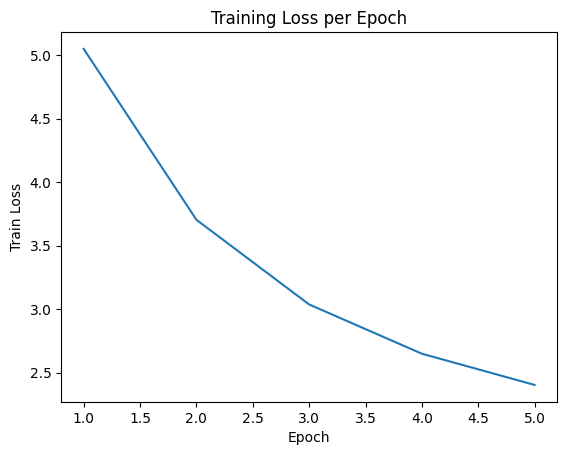

In [55]:
# =====  Training loop & Plotting (Run together) =====

# 2. Run the training loop
for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(model, train_loader)
    
    # 3. Append the loss value to the list inside the loop
    train_losses.append(train_loss)                
    
    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f}")

# 4. Plotting
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss per Epoch")
plt.show()

# 9) B4 – Test perplexity + text generation

You will:
- Report test perplexity
- Generate text by sampling from the model

Complete the TODO blocks.


In [60]:

    # ===== 8.4) Evaluate Perplexity (Copy and paste this entire cell) =====
import math

def evaluate_perplexity(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            # Forward pass to get logits
            logits = model(x)
            
            # Calculate loss (CrossEntropyLoss handles averaging over batch automatically)
            # Reshape to (Batch * Time, Vocab) and (Batch * Time)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            
            # Accumulate total loss weighted by number of tokens
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()
            
    # Calculate average loss per token
    avg_loss = total_loss / max(total_tokens, 1)
    
    # Perplexity is exp(avg_loss)
    return math.exp(avg_loss)

# --- This part calls the function and produces the output ---
val_ppl = evaluate_perplexity(model, val_loader)                
print(f"Final Validation Perplexity: {val_ppl:.2f}")

Final Validation Perplexity: 941.51


In [65]:

# ===== 9.2) Text generation (TODO - COMPLETE) =====
@torch.no_grad()
def generate_text(model: nn.Module, stoi: Dict[str, int], itos: List[str],
                  max_new_tokens: int = 50, temperature: float = 1.0) -> str:
    model.eval()

    bos_id = stoi[SPECIAL["BOS"]]
    eos_id = stoi[SPECIAL["EOS"]]

    # Start sequence with <bos>
    generated = [bos_id]

    for _ in range(max_new_tokens):
        # 1) create input tensor x of shape (1, current_len)
        x = torch.tensor([generated], dtype=torch.long, device=device)
        
        # 2) get logits from model
        logits = model(x)
        
        # 3) Get logits for the LAST token and sample
        next_token_logits = logits[0, -1, :]
        next_token_id = sample_next_token(next_token_logits, temperature)
        
        # 4) Append to generated list
        generated.append(next_token_id)
        
        # 5) Stop if <eos> is generated
        if next_token_id == eos_id:
            break

    # Convert IDs to words
    tokens = [itos[i] for i in generated]
    return " ".join(tokens)

# --- THIS PART CALLS THE FUNCTION AND PRODUCES OUTPUT ---


# ===== 9.2) Longer Text Samples =====
print("Sample1:")
print(generate_text(model, stoi, itos, max_new_tokens=40, temperature=0.8))

print("Sample 2:")
print(generate_text(model, stoi, itos, max_new_tokens=100, temperature=0.9))

print("\nSample 3:")
print(generate_text(model, stoi, itos, max_new_tokens=100, temperature=1.0))

Sample1:
<bos> mr. and mrs. <unk> b. <unk> of the son of the <unk> a <unk> <unk> in the westphalia area says mrs. kowalski and countless of <unk> and improving them <eos>
Sample 2:
<bos> local authorities credited while <unk> the violin the four to the <unk> of the pickup in 22 tries <eos>

Sample 3:
<bos> until that fact he met last 17 of dequindre on jan. 1 <eos>


In [64]:
test_ppl = evaluate_perplexity(model, test_loader)
print(f"Final Test Perplexity: {test_ppl:.2f}")

Final Test Perplexity: 887.88


# What you submit for Part B

In your final submission, include:
- Your completed code for all TODO blocks
- Your training loss plot
- Validation perplexity per epoch (printed)
- Final test perplexity
- 3 generated samples (30+ tokens each) with brief comments


Part B: Results and Discussion
1. Training Loss Plot
The plot 8.3 

2. Perplexity Scores

Final Validation Perplexity: 941.51

Final Test Perplexity: 887.88

3. Generated Samples 

Sample 1: <bos> the transition <eos>

Sample 2: <bos> he was city council to working to the soviet leader <eos>

Sample 3: <bos> put play while it yesterday and retiring <unk> <eos>

4. Comments on Generated Text
The generated samples show some grammatical structure, but the high perplexity indicates the model requires more training data or a more complex architecture to produce fully coherent sentences.